In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

n = 1200

miasta = {
    "Warszawa":   (52.2297, 21.0122, 1.00),
    "Kraków":     (50.0647, 19.9450, 0.75),
    "Wrocław":    (51.1079, 17.0385, 0.65),
    "Poznań":     (52.4064, 16.9252, 0.55),
    "Gdańsk":     (54.3520, 18.6466, 0.55),
    "Łódź":       (51.7592, 19.4560, 0.50),
    "Katowice":   (50.2649, 19.0238, 0.45),
    "Lublin":     (51.2465, 22.5684, 0.30),
    "Białystok":  (53.1325, 23.1688, 0.25),
    "Szczecin":   (53.4285, 14.5528, 0.35),
}

gatunki = ["rock", "pop", "hip-hop", "electronic", "jazz",
           "classical", "folk", "metal", "indie", "reggae"]

typy_obiektow = ["klub", "arena", "stadion", "festiwal", "teatr", "amfiteatr"]
kapacjety = {
    "klub": (200, 1500), "arena": (3000, 15000), "stadion": (20000, 70000),
    "festiwal": (10000, 80000), "teatr": (400, 2000), "amfiteatr": (1500, 8000),
}
cena_bazowa = {
    "rock": 150, "pop": 200, "hip-hop": 180, "electronic": 160, "jazz": 130,
    "classical": 110, "folk": 90, "metal": 140, "indie": 100, "reggae": 110,
}
cena_mnoznik = {
    "klub": 0.7, "arena": 1.3, "stadion": 1.8,
    "festiwal": 1.5, "teatr": 1.2, "amfiteatr": 1.0,
}

start_date = datetime(2024, 1, 1)
daty = [start_date + timedelta(days=int(d)) for d in np.random.randint(0, 730, n)]

wagi = np.array([miasta[m][2] for m in miasta])
miasto = np.random.choice(list(miasta.keys()), n, p=wagi / wagi.sum())
gatunek = np.random.choice(gatunki, n)
typ_obiektu = np.random.choice(typy_obiektow, n,
                                p=[0.40, 0.15, 0.05, 0.10, 0.15, 0.15])

pojemnosc = np.array([np.random.randint(*kapacjety[t]) for t in typ_obiektu])
wypelnienie = np.clip(np.random.beta(5, 2, n), 0.15, 1.0)
sprzedane = (pojemnosc * wypelnienie).astype(int)

cena = np.array([cena_bazowa[g] * cena_mnoznik[t] for g, t in zip(gatunek, typ_obiektu)])
cena = np.round(cena * np.random.uniform(0.7, 1.4, n), -1)
przychod = (cena * sprzedane).astype(int)

df = pd.DataFrame({
    "event_id": range(50001, 50001 + n),
    "data": daty,
    "miasto": miasto,
    "latitude": [miasta[m][0] for m in miasto],
    "longitude": [miasta[m][1] for m in miasto],
    "gatunek": gatunek,
    "typ_obiektu": typ_obiektu,
    "pojemnosc": pojemnosc,
    "bilety_sprzedane": sprzedane,
    "cena_biletu_pln": cena,
    "przychod_pln": przychod,
})

df.to_csv("koncerty_polska.csv", index=False)
print(f"Wygenerowano plik 'koncerty_polska.csv' — {len(df)} koncertów")

Wygenerowano plik 'koncerty_polska.csv' — 1200 koncertów


SHAPE:
(1200, 11)

HEAD:
   event_id       data    miasto  latitude  longitude    gatunek typ_obiektu  \
0     50001 2024-04-12    Poznań   52.4064    16.9252    hip-hop        klub   
1     50002 2025-03-11    Gdańsk   54.3520    18.6466       folk       arena   
2     50003 2024-09-27  Warszawa   52.2297    21.0122  classical        klub   
3     50004 2024-04-16  Katowice   50.2649    19.0238      metal        klub   
4     50005 2024-03-12    Poznań   52.4064    16.9252      metal        klub   

   pojemnosc  bilety_sprzedane  cena_biletu_pln  przychod_pln  
0        410               316            170.0         53720  
1       5799              2512            130.0        326560  
2        634               414            100.0         41400  
3        979               735            100.0         73500  
4       1430               808             80.0         64640  

DTYPES:
event_id                     int64
data                datetime64[us]
miasto                         

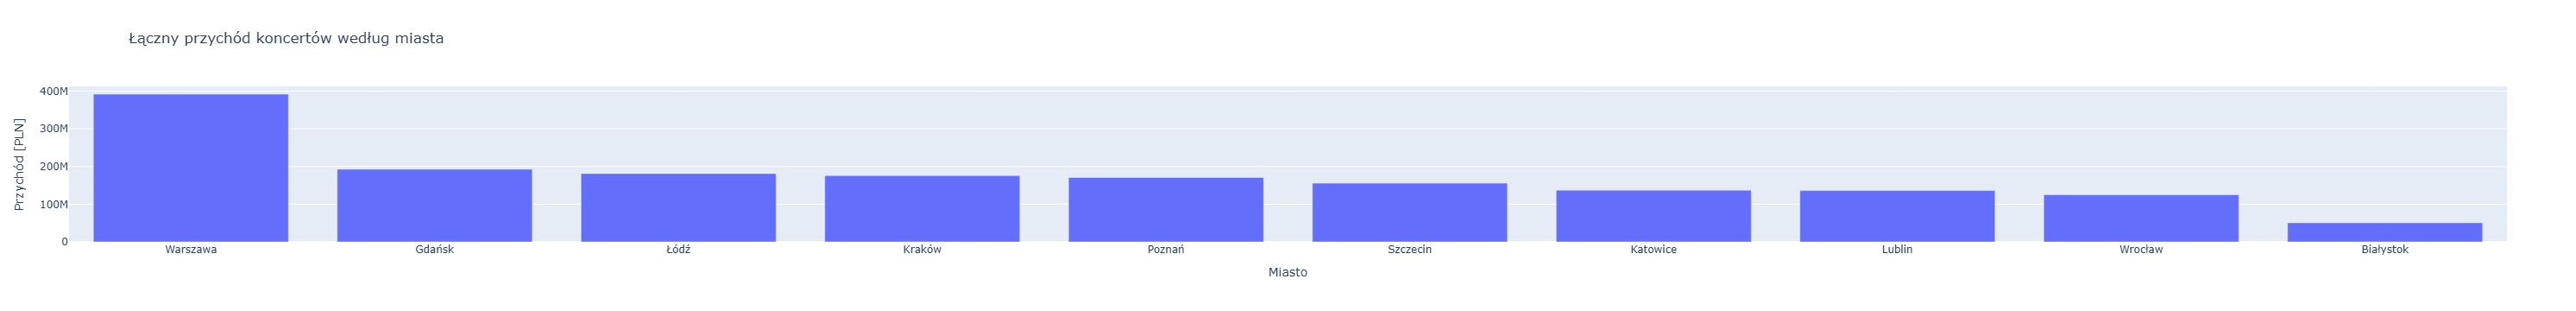

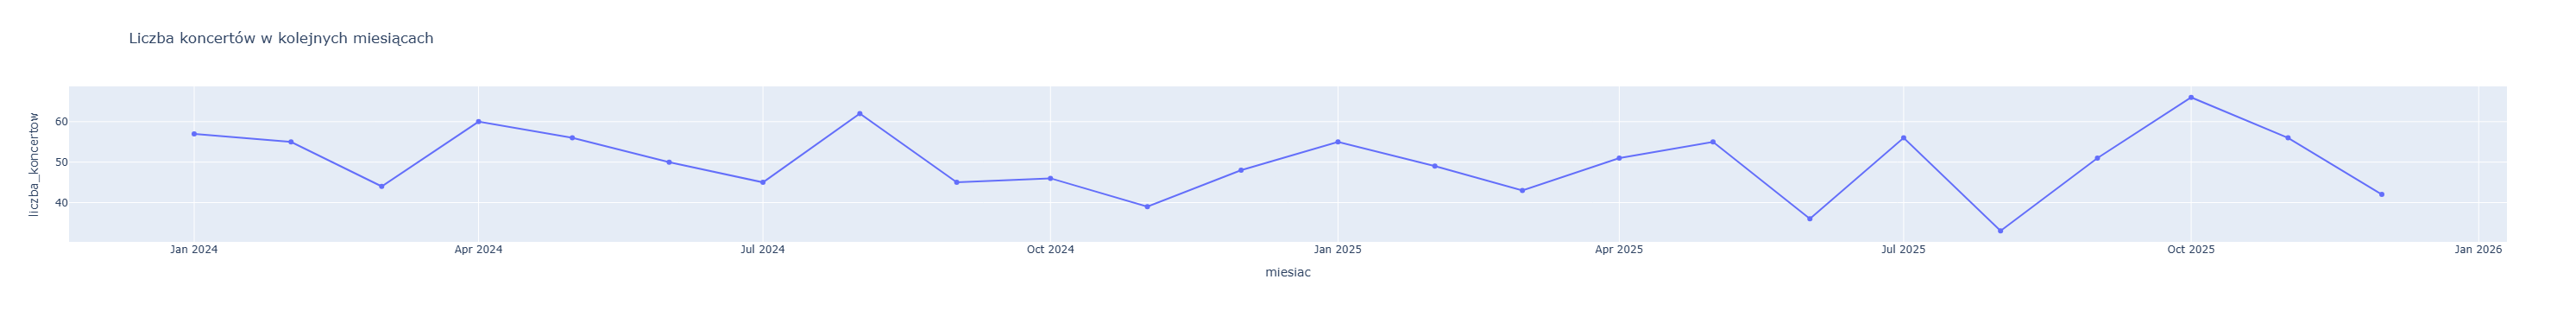

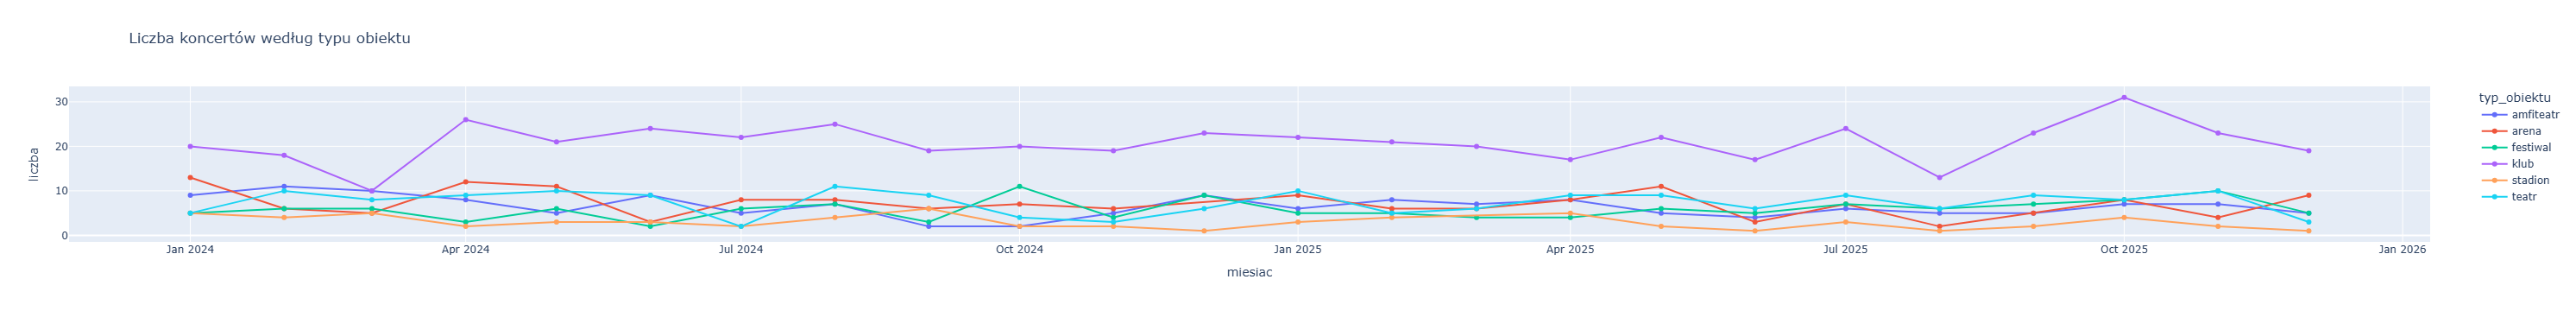

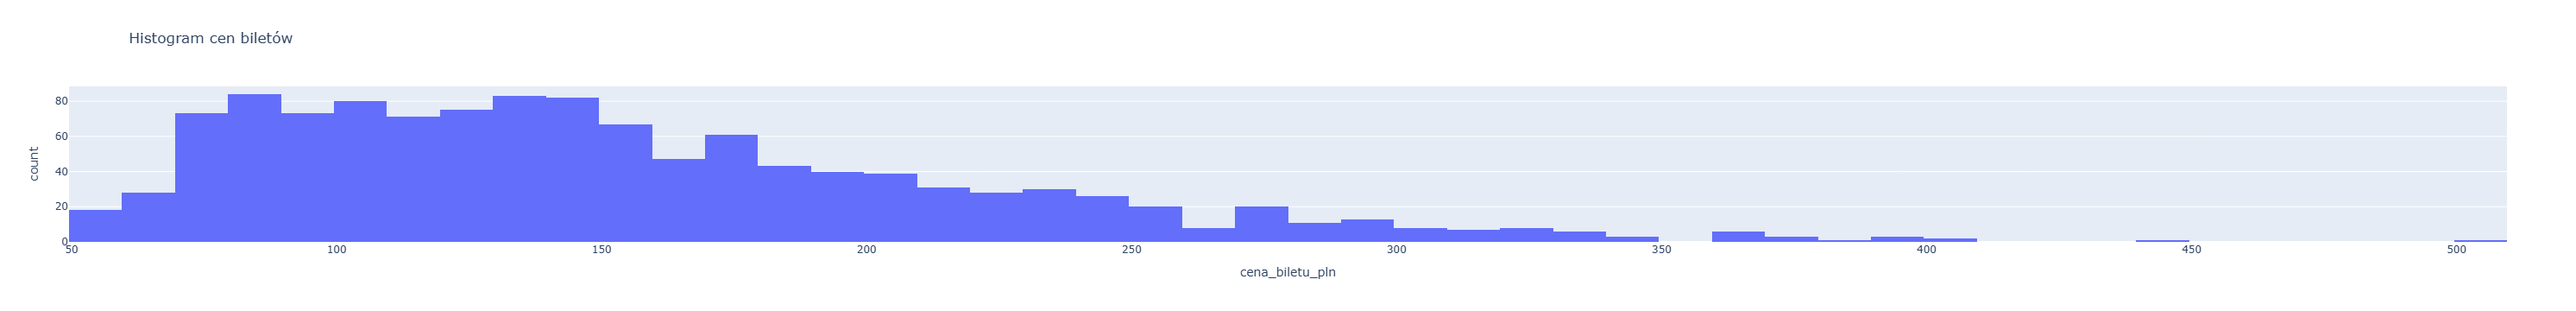

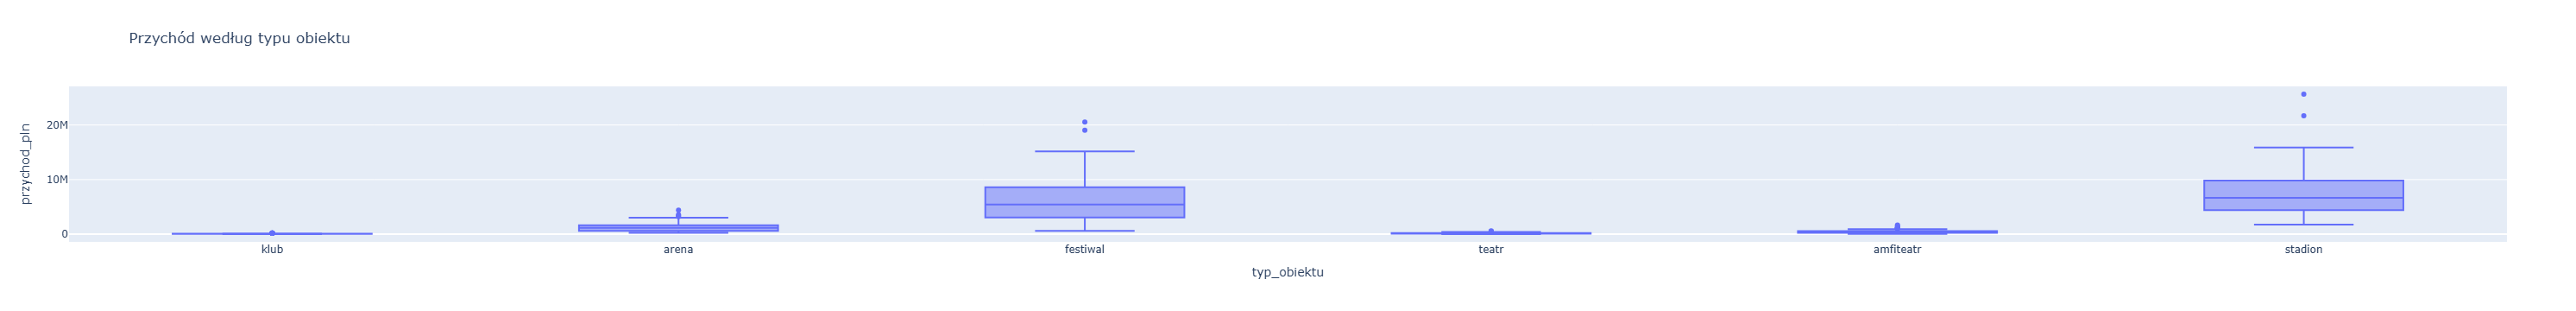

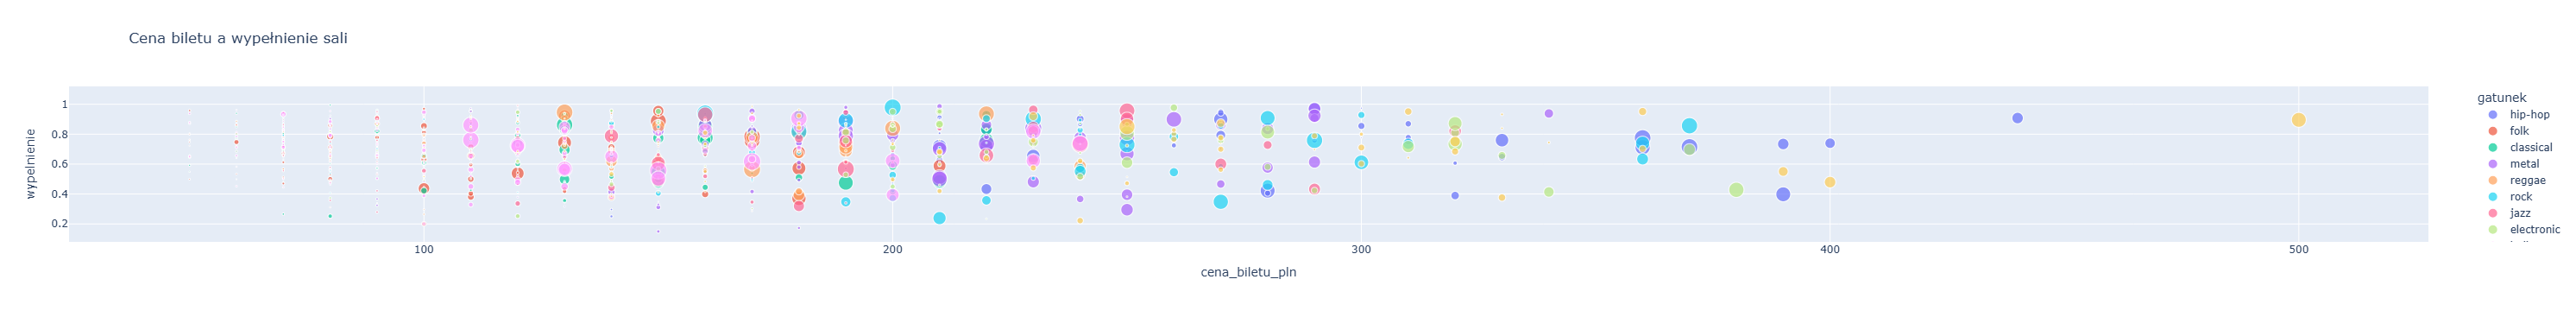

C:\Users\pawel\AppData\Local\Temp\ipykernel_120140\4087923245.py:126: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


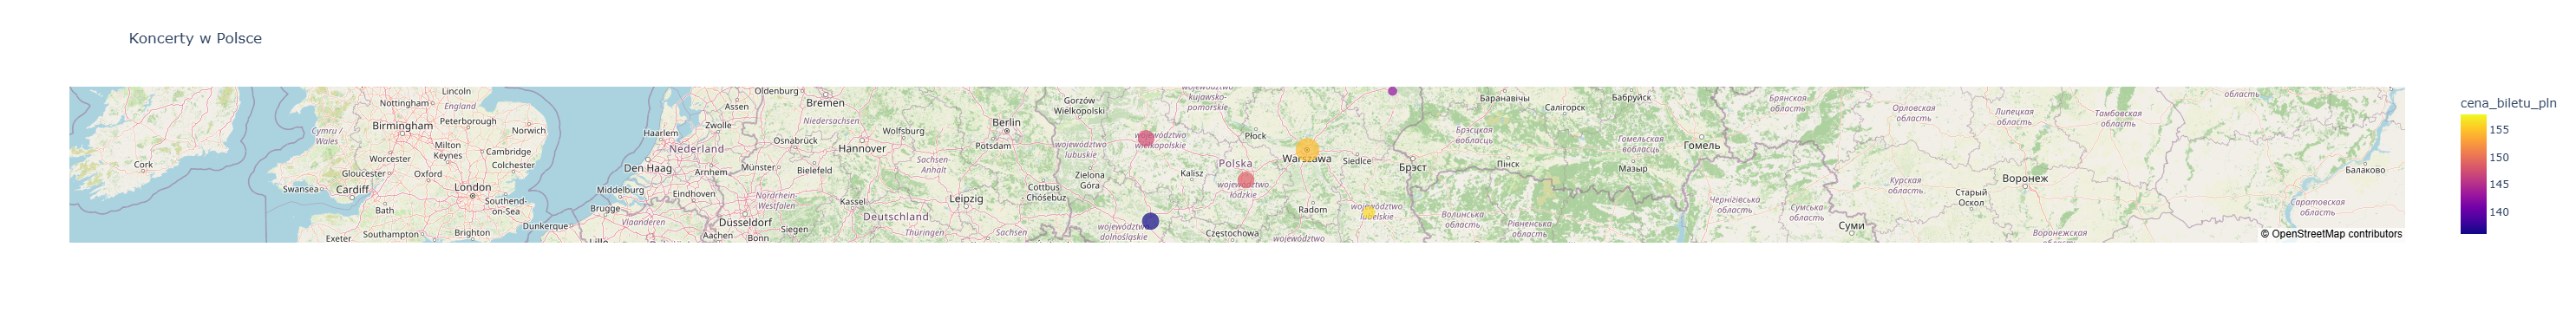

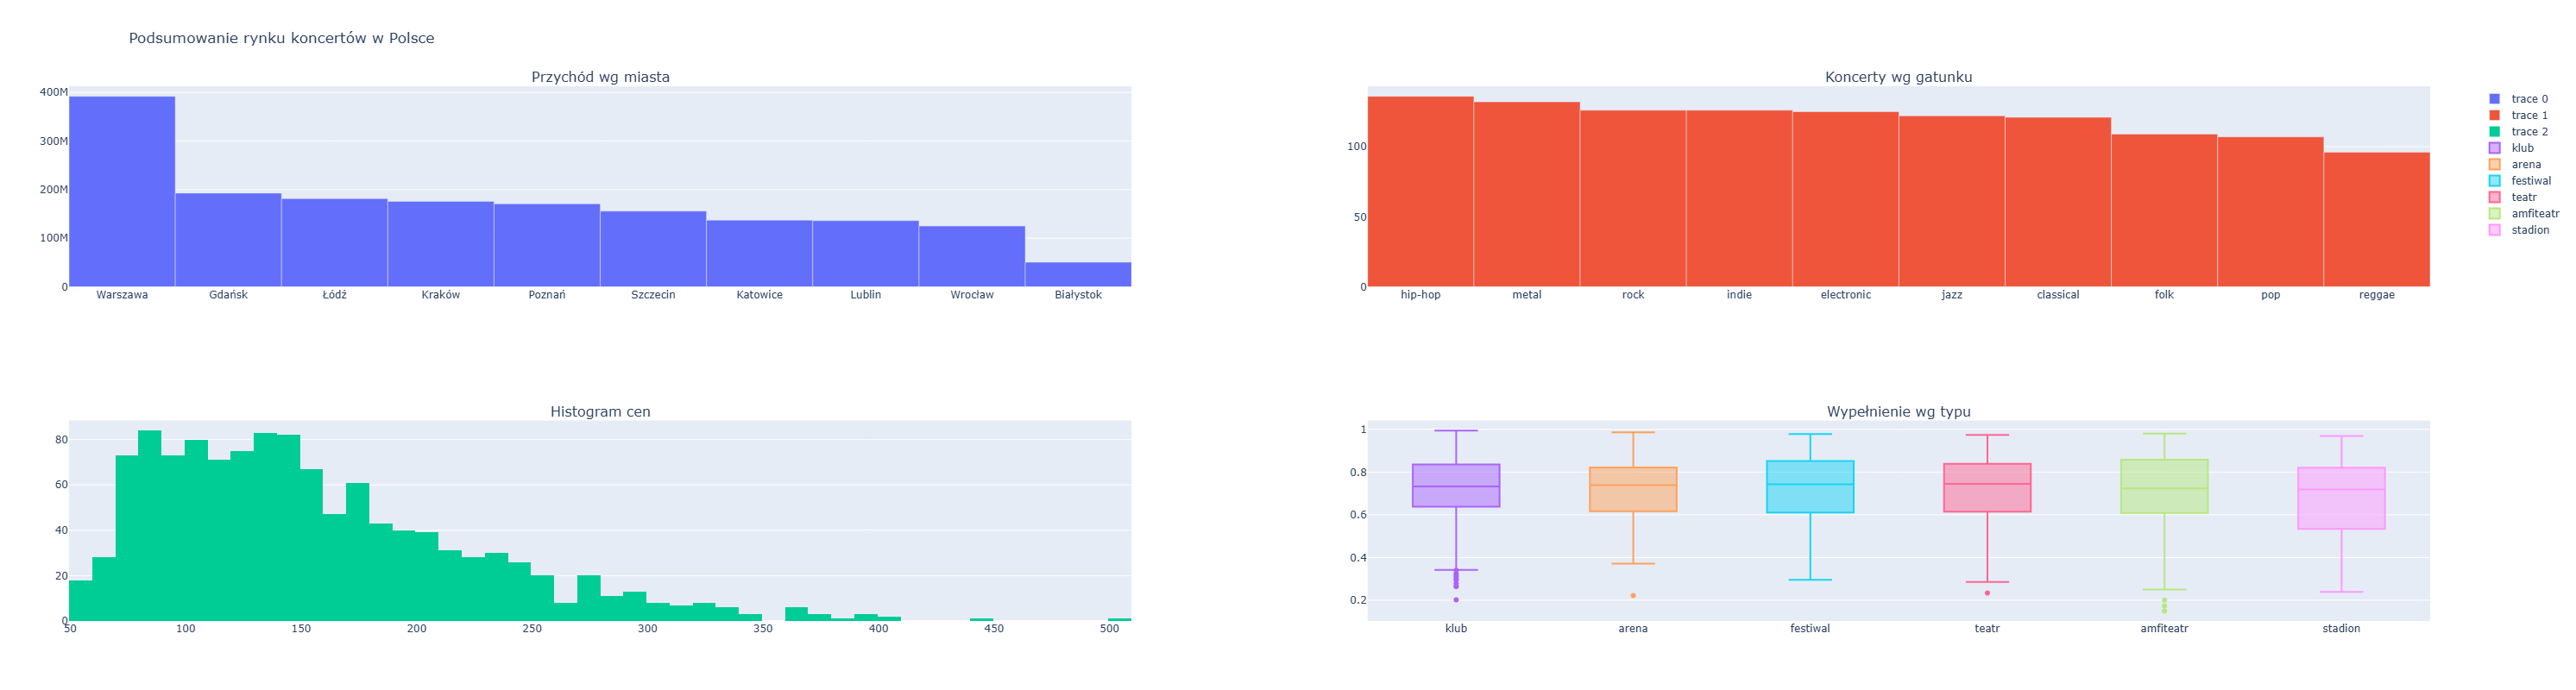


Miasto z największą liczbą koncertów:
miasto
Warszawa    241
Kraków      157
Wrocław     130
Gdańsk      127
Łódź        123
Name: count, dtype: int64

Najwyższa średnia cena biletu:
typ_obiektu
stadion      251.492537
festiwal     212.142857
arena        187.484663
teatr        179.602273
amfiteatr    140.774194
klub         101.062124
Name: cena_biletu_pln, dtype: float64


In [2]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

df = pd.read_csv("koncerty_polska.csv", parse_dates=["data"])

print("SHAPE:")
print(df.shape)

print("\nHEAD:")
print(df.head())

print("\nDTYPES:")
print(df.dtypes)

print("\nLiczba miast:", df["miasto"].nunique())
print("Liczba gatunków:", df["gatunek"].nunique())

miasta = (
    df.groupby("miasto")["przychod_pln"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

fig = px.bar(
    miasta,
    x="miasto",
    y="przychod_pln",
    title="Łączny przychód koncertów według miasta",
    labels={
        "miasto":"Miasto",
        "przychod_pln":"Przychód [PLN]"
    }
)

fig.show()

df["miesiac"] = df["data"].dt.to_period("M").astype(str)

monthly = (
    df.groupby("miesiac")
      .size()
      .reset_index(name="liczba_koncertow")
)

fig = px.line(
    monthly,
    x="miesiac",
    y="liczba_koncertow",
    markers=True,
    title="Liczba koncertów w kolejnych miesiącach"
)

fig.show()

monthly_type = (
    df.groupby(["miesiac","typ_obiektu"])
      .size()
      .reset_index(name="liczba")
)

fig = px.line(
    monthly_type,
    x="miesiac",
    y="liczba",
    color="typ_obiektu",
    markers=True,
    title="Liczba koncertów według typu obiektu"
)

fig.show()

fig = px.histogram(
    df,
    x="cena_biletu_pln",
    nbins=50,
    title="Histogram cen biletów"
)

fig.show()

fig = px.box(
    df,
    x="typ_obiektu",
    y="przychod_pln",
    title="Przychód według typu obiektu"
)

fig.show()

df["wypelnienie"] = (
    df["bilety_sprzedane"] /
    df["pojemnosc"]
)

fig = px.scatter(
    df,
    x="cena_biletu_pln",
    y="wypelnienie",
    color="gatunek",
    size="pojemnosc",
    hover_data=["miasto","typ_obiektu"],
    title="Cena biletu a wypełnienie sali"
)

fig.show()


mapa = (
    df.groupby("miasto")
      .agg({
          "latitude":"first",
          "longitude":"first",
          "cena_biletu_pln":"mean",
          "przychod_pln":"sum",
          "event_id":"count"
      })
      .reset_index()
      .rename(columns={
          "event_id":"liczba_koncertow"
      })
)

fig = px.scatter_mapbox(
    mapa,
    lat="latitude",
    lon="longitude",
    size="liczba_koncertow",
    color="cena_biletu_pln",
    hover_name="miasto",
    hover_data=[
        "liczba_koncertow",
        "cena_biletu_pln",
        "przychod_pln"
    ],
    zoom=5,
    mapbox_style="open-street-map",
    title="Koncerty w Polsce"
)

fig.show()


fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Przychód wg miasta",
        "Koncerty wg gatunku",
        "Histogram cen",
        "Wypełnienie wg typu"
    ]
)

fig.add_trace(
    go.Bar(
        x=miasta["miasto"],
        y=miasta["przychod_pln"]
    ),
    row=1,
    col=1
)

gatunki = (
    df["gatunek"]
    .value_counts()
)

fig.add_trace(
    go.Bar(
        x=gatunki.index,
        y=gatunki.values
    ),
    row=1,
    col=2
)

fig.add_trace(
    go.Histogram(
        x=df["cena_biletu_pln"],
        nbinsx=50
    ),
    row=2,
    col=1
)

for typ in df["typ_obiektu"].unique():
    fig.add_trace(
        go.Box(
            y=df[df["typ_obiektu"]==typ]["wypelnienie"],
            name=typ
        ),
        row=2,
        col=2
    )

fig.update_layout(
    height=800,
    width=1200,
    title="Podsumowanie rynku koncertów w Polsce"
)

fig.show()

print("\nMiasto z największą liczbą koncertów:")
print(df["miasto"].value_counts().head())

print("\nNajwyższa średnia cena biletu:")
print(
    df.groupby("typ_obiektu")["cena_biletu_pln"]
      .mean()
      .sort_values(ascending=False)
)

In [ ]:
1. Warszawa jest zdecydowanym liderem pod względem liczby organizowanych koncertów (241), następnie Kraków (157) i Wrocław (130).

2. Najwyższe średnie ceny biletów występują na koncertach organizowanych na stadionach (ok. 251 zł), a następnie na festiwalach (ok. 212 zł) i w arenach (ok. 187 zł).

3. Koncerty organizowane w klubach mają najniższe średnie ceny biletów (ok. 101 zł), co wynika z mniejszej pojemności obiektów i niższych kosztów organizacji.

4. Największe miasta Polski, takie jak Warszawa, Kraków i Wrocław, skupiają największą liczbę wydarzeń muzycznych, co wskazuje na największy popyt na koncerty właśnie w tych lokalizacjach.

5. Analiza wykresów pokazuje sezonowość rynku koncertowego – w niektórych miesiącach liczba organizowanych wydarzeń jest wyraźnie większa niż w pozostałych.